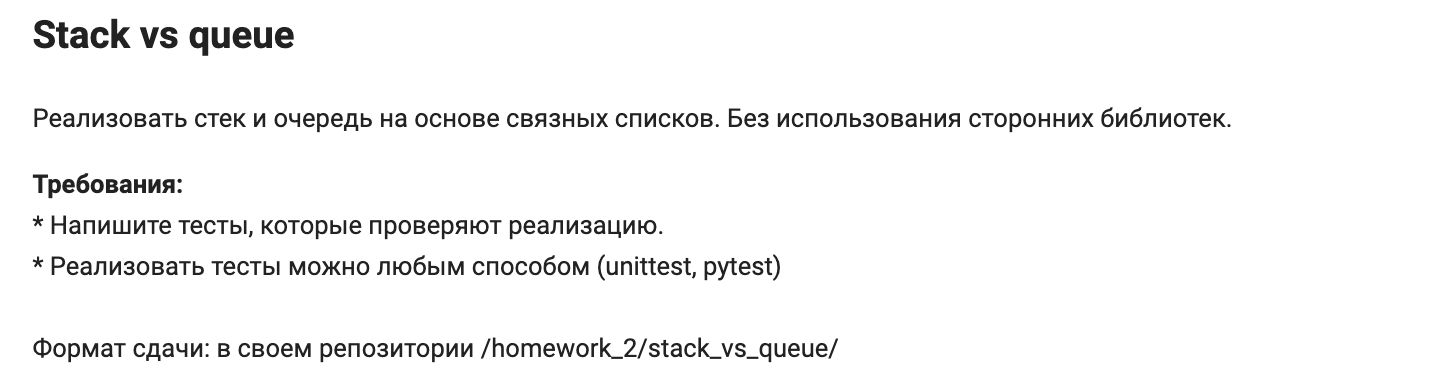

## Ход решения

### Stack

Стек работает по принципу **LIFO**: последний добавленный элемент извлекается первым. `head` указывает на вершину стека.

- `push` добавляет новый элемент на вершину. Для этого создаём новую `Node`, записываем в неё новое значение, а в `next` передаём текущий `head`, то есть оставшуюся часть стека. После этого новый узел становится новым `head`.
- `pop` сначала проверяет, что стек не пустой. Затем сохраняем значение текущей вершины, сдвигаем `head` на следующий узел и возвращаем сохранённое значение. Таким образом верхний элемент удаляется, а вершиной становится следующий.
- `peek` также сначала проверяет, что стек не пустой, после чего просто возвращает значение `head`, не изменяя сам стек.
- `is_empty` проверяет, равен ли `head` значению `None`. Если да, то в стеке нет элементов.

### Queue

Очередь работает по принципу **FIFO**: первый добавленный элемент извлекается первым. `head` указывает на начало очереди, а `tail` — на конец.

- `enqueue` добавляет новый элемент в конец очереди. Сначала создаём новую `Node`. Если очередь пустая, то этот узел одновременно является и началом, и концом, поэтому `head` и `tail` указывают на него. Если элементы уже есть, то через `tail.next` присоединяем новый узел к текущему концу очереди, после чего переносим `tail` на новый узел.
- `dequeue` сначала проверяет, что очередь не пустая. Затем сохраняем значение текущего `head`, после чего сдвигаем `head` на следующий узел. Если после этого элементов не осталось, нужно также установить `tail = None`, иначе он продолжит указывать на уже удалённый последний элемент. В конце возвращаем сохранённое значение.
- `peek` проверяет, что очередь не пустая, и возвращает значение первого элемента, то есть `head.val`, не удаляя его.
- `is_empty` проверяет, равен ли `head` значению `None`. Если да, очередь пустая.

## Сложность алгоритмов

Смысл этих структур данных в том, что основные операции с нужным концом структуры должны выполняться за константное время`O(1)`, то есть время их выполнения не должно зависеть от количества элементов.

### Stack

Для стека важно уметь за `O(1)` работать с его вершиной: добавлять новый элемент, удалять верхний и смотреть его значение.

| Что должно быть | Функция | Время | Доп. память |
| --- | --- | ---: | ---: |
| Добавить элемент на вершину | `push` | `O(1)` | `O(1)` |
| Удалить и вернуть верхний элемент | `pop` | `O(1)` | `O(1)` |
| Посмотреть верхний элемент | `peek` | `O(1)` | `O(1)` |
| Проверить, пуст ли стек | `is_empty` | `O(1)` | `O(1)` |

Такая сложность получается благодаря тому, что `head` всегда указывает на вершину стека. При `push` мы создаём один новый узел и связываем его с текущим `head`, а при `pop` просто переносим `head` на следующий узел. Проходить по всему связному списку ни в одной из этих операций не требуется.

Сам стек при хранении `n` элементов занимает `O(n)` памяти, поскольку для каждого элемента создаётся отдельная `Node`.

### Queue

Для очереди важно за `O(1)` добавлять элементы в конец и удалять их из начала. Поэтому мы храним сразу две ссылки: `head` на начало очереди и `tail` на её конец.

| Что должно быть | Функция | Время | Доп. память |
| --- | --- | ---: | ---: |
| Добавить элемент в конец | `enqueue` | `O(1)` | `O(1)` |
| Удалить и вернуть первый элемент | `dequeue` | `O(1)` | `O(1)` |
| Посмотреть первый элемент | `peek` | `O(1)` | `O(1)` |
| Проверить, пуста ли очередь | `is_empty` | `O(1)` | `O(1)` |

`enqueue` работает за `O(1)`, потому что благодаря `tail` нам не нужно проходить весь список в поиске его конца: новый узел сразу присоединяется к `tail`, после чего `tail` переносится на него. `dequeue` также работает за `O(1)`, поскольку `head` сразу указывает на первый элемент и для удаления достаточно перенести его на `head.next`. `peek` и `is_empty` работают напрямую с `head`, поэтому также не требуют прохода по списку.

Вся очередь для `n` элементов занимает `O(n)` памяти, а каждая отдельная операция использует только `O(1)` дополнительной памяти.

# Реализация

Сначала реализуем класс Node, где в вершину складываем значение `val` и ссылку на следующую ноду: `next_node`

In [5]:
class Node:
    def __init__(self, val=0, next_node=None):
        self.val = val
        self.next = next_node

Затем реализуем Stack согласно алгоритму выше

In [6]:
class Stack:
    def __init__(self):
        self.head = None

    def push(self, val):
        self.head = Node(val, self.head)

    def pop(self):
        if self.head is None:
            raise IndexError("pop from empty stack")

        val = self.head.val
        self.head = self.head.next
        return val

    def peek(self):
        if self.head is None:
            raise IndexError("peek from empty stack")

        return self.head.val

    def is_empty(self):
        return self.head is None

Наконец делаем очередь

In [7]:
class Queue:
    def __init__(self):
        self.head = None
        self.tail = None

    def enqueue(self, val):
        node = Node(val)

        if self.tail is None:
            self.head = self.tail = node
            return

        self.tail.next = node
        self.tail = node

    def dequeue(self):
        if self.head is None:
            raise IndexError("dequeue from empty queue")

        val = self.head.val
        self.head = self.head.next

        if self.head is None:
            self.tail = None

        return val

    def peek(self):
        if self.head is None:
            raise IndexError("peek from empty queue")

        return self.head.val

    def is_empty(self):
        return self.head is None

# Визуализация работы алгоритма

## Stack

Выполним `push(10)`, `push(20)`, `push(30)`, затем `pop()`.

| Шаг | Состояние стека | `head` | Результат |
| --- | --- | ---: | --- |
| Начало | `None` | `None` | пустой стек |
| `push(10)` | `10 -> None` | `10` | — |
| `push(20)` | `20 -> 10 -> None` | `20` | — |
| `push(30)` | `30 -> 20 -> 10 -> None` | `30` | — |
| `pop()` | `20 -> 10 -> None` | `20` | возвращает `30` |

## Queue

Выполним `enqueue(10)`, `enqueue(20)`, `enqueue(30)`, затем `dequeue()`.

| Шаг | Состояние очереди | `head` | `tail` | Результат |
| --- | --- | ---: | ---: | --- |
| Начало | `None` | `None` | `None` | пустая очередь |
| `enqueue(10)` | `10 -> None` | `10` | `10` | — |
| `enqueue(20)` | `10 -> 20 -> None` | `10` | `20` | — |
| `enqueue(30)` | `10 -> 20 -> 30 -> None` | `10` | `30` | — |
| `dequeue()` | `20 -> 30 -> None` | `20` | `30` | возвращает `10` |

# Тесты

Тесты проверяют не только основной сценарий работы стека и очереди, но и граничные случаи.

Для **Stack** проверяется:
- что новый стек изначально пустой;
- что `push` добавляет элементы в правильном порядке;
- что `peek` возвращает верхний элемент, не удаляя его;
- что `pop` извлекает элементы по принципу **LIFO**;
- что после удаления всех элементов стек снова становится пустым;
- что попытка выполнить `pop` для пустого стека корректно приводит к `IndexError`.

Для **Queue** проверяется:
- что новая очередь изначально пустая;
- что `enqueue` добавляет элементы в конец;
- что `peek` возвращает первый элемент очереди без удаления;
- что `dequeue` извлекает элементы по принципу **FIFO**;
- что после удаления всех элементов очередь становится пустой;
- что после удаления последнего элемента и `head`, и `tail` равны `None`;
- отдельно проверяется граничный случай очереди из одного элемента: после его удаления структура должна полностью вернуться в пустое состояние;
- что попытка выполнить `dequeue` для пустой очереди корректно приводит к `IndexError`.

Таким образом тесты покрывают как типичную работу структур с несколькими элементами, так и основные граничные состояния: пустая структура, удаление последнего элемента и попытка удаления из уже пустой структуры.

In [4]:
stack = Stack()
assert stack.is_empty()

stack.push(10)
stack.push(20)
stack.push(30)
assert stack.peek() == 30
assert stack.pop() == 30
assert stack.pop() == 20
assert stack.pop() == 10
assert stack.is_empty()

try:
    stack.pop()
    assert False
except IndexError:
    pass

queue = Queue()
assert queue.is_empty()

queue.enqueue(10)
queue.enqueue(20)
queue.enqueue(30)
assert queue.peek() == 10
assert queue.dequeue() == 10
assert queue.dequeue() == 20
assert queue.dequeue() == 30
assert queue.is_empty()
assert queue.head is None
assert queue.tail is None

queue.enqueue(42)
assert queue.dequeue() == 42
assert queue.head is None
assert queue.tail is None

try:
    queue.dequeue()
    assert False
except IndexError:
    pass

print("Все тесты пройдены")

Все тесты пройдены
